# Quantum Computing Lab - Assignment 3
## Mrudula A Mahindrakar
## EE25S011

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import AerSimulator, Aer
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_histogram, plot_state_city, plot_bloch_multivector
from qiskit.quantum_info import Statevector, DensityMatrix, Operator, state_fidelity, partial_trace

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from IPython.display import display

In [3]:
QiskitRuntimeService.save_account(
token="", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True # Optional: Overwrite existing saved accounts
)
service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
sim_backend = AerSimulator() # Use simulator by default

print(backend.name)

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]
ibm_torino


# Problem 1 - Implementing the Deutsch-Jozsa algorithm on IBMQ
1. Consider the 3-bit Boolean function f(x) = x0 ⊕x1x2. Check whether the function is constant or balanced, classically! How many queries did you need?
2. Construct the quantum oracle Uf corresponding to this function, and hence develop a circuit to implement the Deutsch-Jozsa algorithm to check whether the function is constant or balanced, using a single query. Demonstrate the D-J algorithm by running this circuit on a noiseless simulator.
3. Implement the same circuit for the D-J algorithm on a noisy quantum simulator, by injecting your favourite noise model (bit-flip/phaseflip/amplitude damping/coherent errors) for the qubits! How different is the result?

We are given the 3-bit Boolean function: $ f(x_0, x_1, x_2) = x_0 \oplus (x_1 x_2) $

### Truth Table

| $x_0$ | $x_1$ | $x_2$ | $x_1x_2$ | $f(x)$ |
|----------|----------|----------|-------------|------------|
| 0 | 0 | 0 | 0 | 0 |
| 0 | 0 | 1 | 0 | 0 |
| 0 | 1 | 0 | 0 | 0 |
| 0 | 1 | 1 | 1 | 1 |
| 1 | 0 | 0 | 0 | 1 |
| 1 | 0 | 1 | 0 | 1 |
| 1 | 1 | 0 | 0 | 1 |
| 1 | 1 | 1 | 1 | 0 |


The truth table has 4 inputs as 1's and 4 outputs are 1's, which means the function is balanced.

To determine whether a 3-bit function is constant or balanced clasically, we must evaluate 5 inputs. ($2^{n-1}$)


## Deutsch–Jozsa Algorithm

The quantum oracle is defined as $ U_f \vert x\rangle \vert y\rangle = \vert x\rangle \vert y \oplus f(x)\rangle $

The oracle can be implemented using CNOT and Toffoli gates.

Initialize $ \vert000\rangle \vert1\rangle $

Apply $H$ to all qubits, $ \frac{1}{\sqrt{8}} \sum_x \vert x\rangle \;\otimes\;\frac{\vert 0\rangle - \vert 1\rangle}{\sqrt{2}} $

The output qubit is now in $ \vert -\rangle = \frac{\vert 0\rangle - \vert 1\rangle}{\sqrt{2}} $

Because the output qubit is in $\vert -\rangle$, we obtain, $ \frac{1}{\sqrt{8}} \sum_x (-1)^{f(x)} \vert x\rangle $

The function values are now encoded as phases.

We apply $H^{\otimes 3}$ to the input qubits.

Final measurement probabilities depend on whether f(x) is:

- Constant $\rightarrow$ amplitude only on $ \vert 000\rangle $
- Balanced $\rightarrow$ amplitude of $ \vert 000\rangle = 0 $

Since the function is balanced, The state $ \vert 000\rangle $ will never be measured.

The measurement outcome will be some non-zero bitstring.

The Deutsch-Jozsa Algorithm only takes a single query to complete the algorithm.

The function $f(x) = x_0 \oplus (x_1 x_2) $ is balanced.


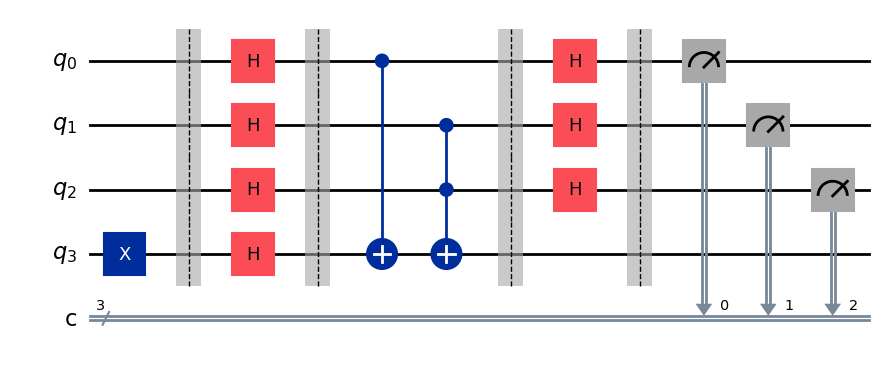

In [28]:
qc=QuantumCircuit(4,3)

qc.x(3)
qc.barrier()

qc.h(range(4))
qc.barrier()

# Oracle
qc.cx(0,3)
qc.ccx(1,2,3)
qc.barrier()

qc.h(range(3))
qc.barrier()

# Measurements
qc.measure(range(3),range(3))

# Draw Circuit
qc.draw('mpl')

Measurement Results: {'001': 258, '011': 254, '111': 267, '101': 245}


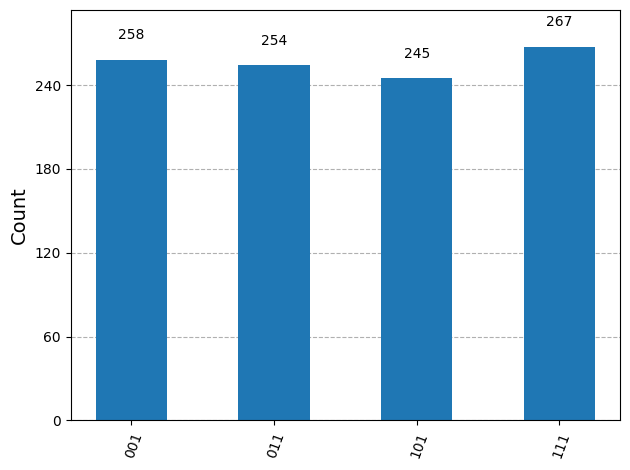

In [29]:
backend = Aer.get_backend("aer_simulator")
result = backend.run(qc, shots=1024).result()
counts = result.get_counts()
print("Measurement Results:", counts)
plot_histogram(counts)

We see that no outcome is obtained corresponding to $000$. Hence the function must be balanced.

Noisy Results: {'101': 208, '001': 224, '111': 256, '011': 239, '000': 59, '010': 15, '110': 15, '100': 8}


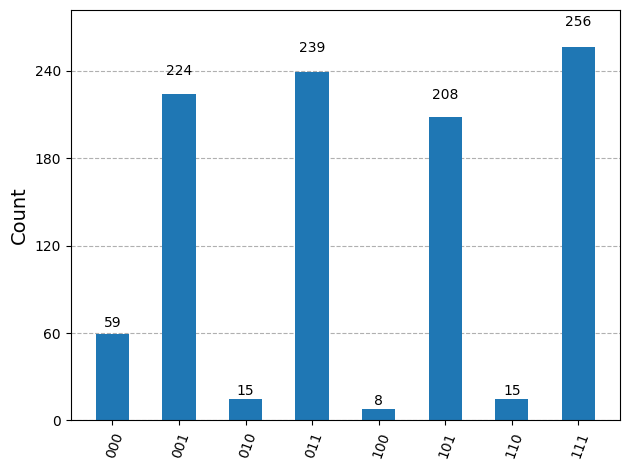

In [30]:
# Noisy simulator Model

# bit flip noise model
p_error = 0.05

error_1 = pauli_error([('X', p_error), ('I', 1 - p_error)])
error_2 = error_1.tensor(error_1)
error_3 = error_1.tensor(error_1).tensor(error_1) 

noise_model = NoiseModel()

noise_model.add_all_qubit_quantum_error(error_1, ['h', 'x'])
noise_model.add_all_qubit_quantum_error(error_2, ['cx'])
noise_model.add_all_qubit_quantum_error(error_3, ['ccx'])

noisy_sim = AerSimulator(noise_model=noise_model)

qc_transpiled = transpile(qc, noisy_sim)
job = noisy_sim.run(qc_transpiled, shots=1024)
result = job.result()
noisy_counts = result.get_counts()

print("Noisy Results:", noisy_counts)

plot_histogram(noisy_counts)

Under a p=0.05 bit-flip noise model, the output histogram becomes significantly spread across multiple bitstrings. 
The state $\vert 000 \rangle $ appears with a small probability.

# Problem 2 - Grover Search
In this exercise we will work out the Grover oracle for a certain Boolean satisfiability problem called 3-SAT. Consider the following Boolean function of three binary variables $ f(x_1,x_2,x_3) = (x_1 \vee x_2 \vee x_3) \wedge (\neg x_1 \vee x_2 \vee x_3) \wedge (\neg x_1 \vee \neg x_2 \vee x_3) \wedge (\neg x_1 \vee \neg x_2 \vee \neg x_3) \wedge (x_1 \vee x_2 \vee \neg x_3) \wedge (\neg x_1 \vee x_2 \vee \neg x_3) $

1. Write down the truth table for this function and show that there are exactly two input strings for which the function $f(x1, x2, x3) = 1$. In other words, there are exactly two satisfying assignments for the Boolean function f.
2. We can recast the 3-SAT problem as a search problem, by constructing an oracle that identifies the input strings for which the function $f$ is satisfied. Construct a quantum oracle corresponding to this search problem.
3. Use Grover search to identify the solutions to the 3-SAT search problem. How many queries does the quantum oracle need, to converge on an input string that satisfies the given Boolean function?
4. Obtain the results of the Grover search on both noiseless and noisy quantum simulators using the IBMQ platform.

The truth table: 
| $x_1$ | $x_2$ | $x_3$ | $f(x_1,x_2,x_3)$ |
|----|----|----|-------------|
| 0 | 0 | 0 | 0 |
| 0 | 0 | 1 | 0 |
| 0 | 1 | 0 | 1 |
| 0 | 1 | 1 | 1 |
| 1 | 0 | 0 | 0 |
| 1 | 0 | 1 | 0 |
| 1 | 1 | 0 | 0 |
| 1 | 1 | 1 | 0 |

Thus, $ f = 1 $ only for $(0,1,0)$ and $(0,1,1) $.

Grover's oracle must implement $ U_f \vert x\rangle = (-1)^{f(x)} \vert x\rangle $. So we will flip the phase of the two active bits.

The Grover search requires $ r \approx \frac{\pi}{4}\sqrt{\frac{N}{M}} $ where N=8 and M=2. 

$ r = \frac{\pi}{4}\sqrt{\frac{8}{2}} = \frac{\pi}{4}\sqrt{4} = \frac{\pi}{4} \times 2 = \frac{\pi}{2} \approx 1.57 $ $\rightarrow$ Thus, only one oracle query is required.

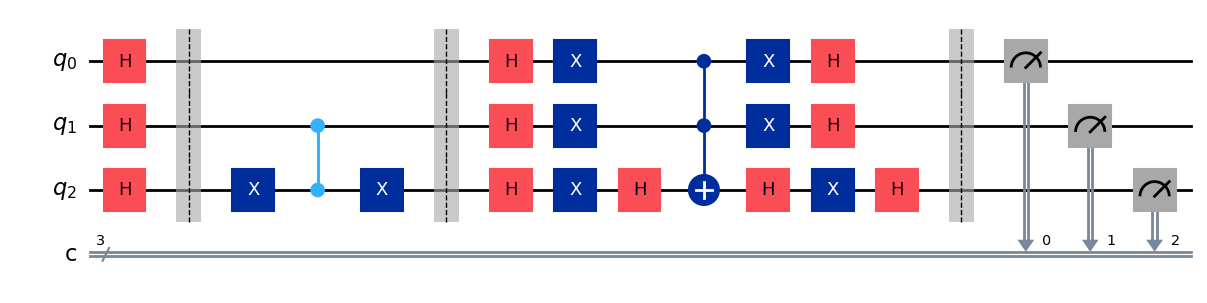

In [8]:
qc = QuantumCircuit(3,3)

# Step 1: Superposition
qc.h([0,1,2])
qc.barrier()

# ORACLE needs to mark |010> and |011>
# detect x1 = 0
qc.x(2)         
qc.cz(2,1)      
# phase flip when x1=0 and x2=1
qc.x(2)
qc.barrier()

# diffuser
qc.h([0,1,2])
qc.x([0,1,2])

qc.h(2)
qc.ccx(0,1,2)
qc.h(2)

qc.x([0,1,2])
qc.h([0,1,2])
qc.barrier()

# measurement
qc.measure([0,1,2],[0,1,2])

display(qc.draw("mpl"))

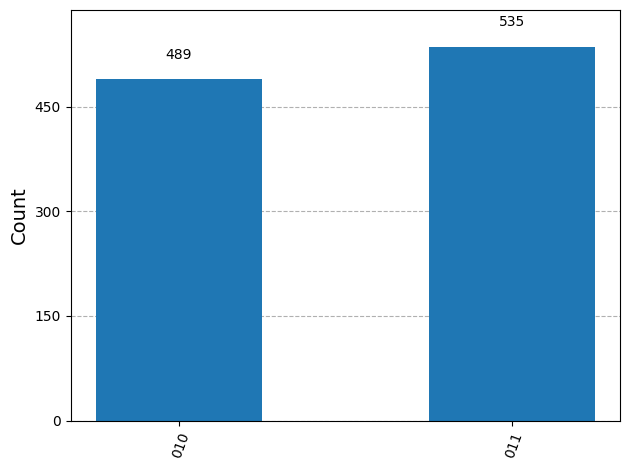

In [9]:
# Noiseless Simulator
sim = AerSimulator()
result = sim.run(transpile(qc,sim),shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

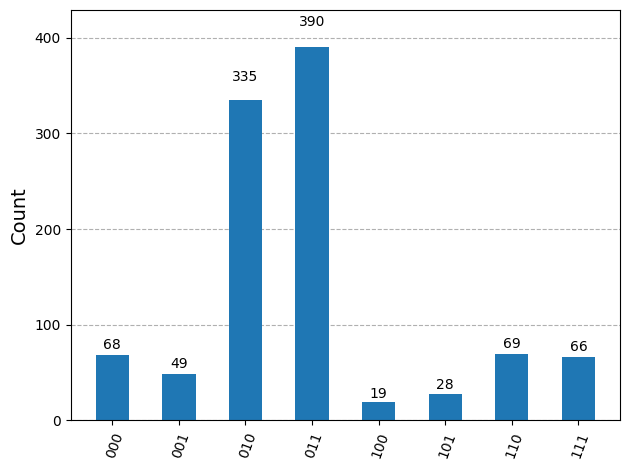

In [10]:
# Noisy model
p = 0.02

error1 = pauli_error([('X', p), ('I', 1-p)])
error2 = error1.tensor(error1)

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error1, ['h','x'])
noise_model.add_all_qubit_quantum_error(error2, ['cx'])

noisy_sim = AerSimulator(noise_model=noise_model)

result_noisy = noisy_sim.run(
    transpile(qc,noisy_sim),
    shots=1024
).result()

counts_noisy = result_noisy.get_counts()
plot_histogram(counts_noisy)
